Project Description and Data OverviewThe Problem: The dairy industry needs to predict future milk production to optimize supply chains, manage inventory, and plan workforce activities.The Data: The dataset contains monthly production figures from January 1962 to December 1975. It exhibits a clear upward trend and strong seasonal fluctuations (peaks in summer, dips in winter).The Goal: Build and compare three models to forecast the next 12 months of production.

<Axes: title={'center': 'Monthly Milk Production'}, xlabel='Date'>

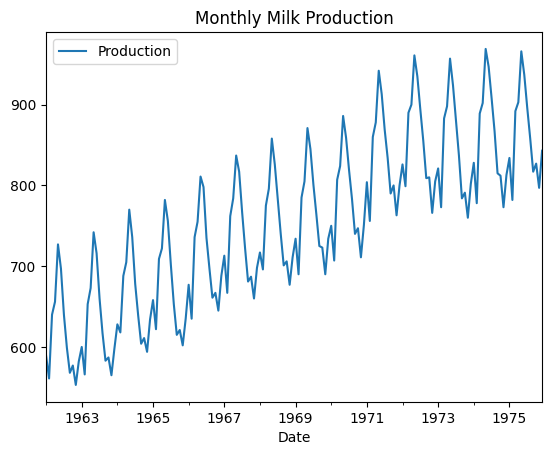

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

# Load dataset
df = pd.read_csv('monthly_milk_production (2).csv', index_col='Date', parse_dates=True)
df.plot(title="Monthly Milk Production") 

In [21]:
df.head()

,Production
Date,
1962-01-01,589
1962-02-01,561
1962-03-01,640
1962-04-01,656
1962-05-01,727


In [22]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 168 entries, 1962-01-01 to 1975-12-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Production  168 non-null    int64
dtypes: int64(1)
memory usage: 2.6 KB


In [23]:
df.shape

(168, 1)

In [24]:
df.describe()

,Production
count,168.000000
mean,754.708333
std,102.204524
min,553.000000
25%,677.750000
50%,761.000000
75%,824.500000
max,969.000000


Train-Test Split (Last 12 months for testing)

In [25]:
##Train-Test Split (Last 12 months for testing) [cite: 22]
train = df.iloc[:-12]
test = df.iloc[-12:]

In [26]:
# Scaling the data (Now it only contains numeric 'Production' values)
scaler = MinMaxScaler()
scaler.fit(train)

scaled_train = scaler.transform(train)
scaled_test = scaler.transform(test)

Step 2: Data Preparation for Deep Learning

We create 12-month windows to feed into the models.

In [28]:
n_input = 12  # Use 12 months to predict the 13th
n_features = 1

generator = TimeseriesGenerator(scaled_train, scaled_train, length=n_input, batch_size=1)

### Step 3: Model Building (RNN, LSTM, GRU)

We define the three separate architectures specified in your assignment.

In [29]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU

def build_model(model_type):
    model = Sequential()
    if model_type == 'RNN':
        model.add(SimpleRNN(100, activation='relu', input_shape=(n_input, n_features))) # [cite: 66]
    elif model_type == 'LSTM':
        model.add(LSTM(100, activation='relu', input_shape=(n_input, n_features))) # [cite: 67]
    elif model_type == 'GRU':
        model.add(GRU(100, activation='relu', input_shape=(n_input, n_features))) # [cite: 68]
    
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse') # [cite: 70]
    return model

# Train the LSTM as an example
model = build_model('LSTM')
model.fit(generator, epochs=50)

c:\Users\saipr\anaconda3\Detecting-Mines-vs-Rocks\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0432
Epoch 2/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0234
Epoch 3/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0167
Epoch 4/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0186
Epoch 5/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0101
Epoch 6/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0087
Epoch 7/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0064
Epoch 8/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0060
Epoch 9/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0056
Epoch 10/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0049
Epoch 11/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0065
Epoch 12/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0049
Epoch 13/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0045
Epoch 14/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0042
Epoch 15/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - lo

### Step 4: Evaluation & Prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


<Axes: title={'center': 'Actual vs Predicted Production'}, xlabel='Date'>

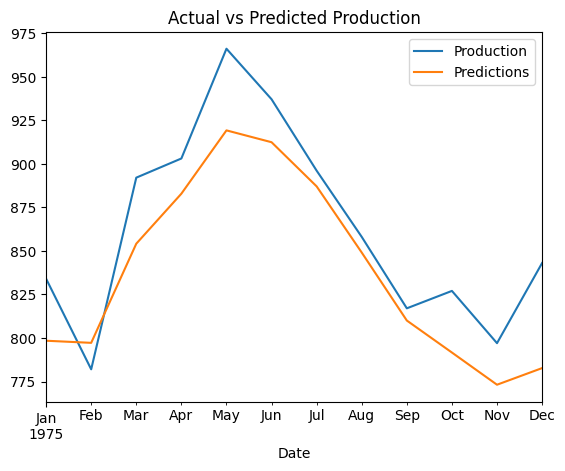

In [ ]:
test_predictions = []
first_eval_batch = scaled_train[-n_input:]
current_batch = first_eval_batch.reshape((1, n_input, n_features))

for i in range(len(test)):
    current_pred = model.predict(current_batch)[0]
    test_predictions.append(current_pred) 
    current_batch = np.append(current_batch[:,1:,:], [[current_pred]], axis=1)

true_predictions = scaler.inverse_transform(test_predictions)
test['Predictions'] = true_predictions
test.plot(title="Actual vs Predicted Production")